<a target="_blank" href="https://colab.research.google.com/github/genomicsxai/alphagenome-pytorch/blob/main/examples/notebooks/in_silico_mutagenesis.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# In-Silico Mutagenesis (ISM) with AlphaGenome

This notebook demonstrates how to perform in-silico mutagenesis (ISM) to systematically
identify functional variants by scoring all possible single-nucleotide mutations in a
genomic window.

ISM is useful for:
- Identifying causal variants in GWAS loci
- Characterizing regulatory element function
- Prioritizing variants for experimental validation

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from alphagenome_pytorch import AlphaGenome
from alphagenome_pytorch.config import DtypePolicy
from alphagenome_pytorch.variant_scoring import (
    VariantScoringModel, Variant, Interval,
    CenterMaskScorer, OutputType, AggregationType,
)

## 1. Load Model and Create Scoring Wrapper

In [ ]:
# Paths - adjust these for your setup
TORCH_WEIGHTS_PATH = '../../ag_pytorch_model.pth'
FASTA_PATH = '../../data/annotations/hg38.fa'
GTF_PATH = '../../data/annotations/gencode.v46.annotation.parquet'
METADATA_PATH = '../../track_metadata.parquet'

model = AlphaGenome(num_organisms=2, dtype_policy=DtypePolicy.full_float32())
checkpoint = torch.load(TORCH_WEIGHTS_PATH, map_location='cpu')
model.load_state_dict(checkpoint['state_dict'])

model.eval()
model.cuda()

# Create scoring wrapper
scoring_model = VariantScoringModel(
    model,
    fasta_path=FASTA_PATH,
    gtf_path=GTF_PATH,
    default_organism='human',
)
scoring_model.load_all_metadata(METADATA_PATH)

print(f"Model loaded on {scoring_model.device}")

Model loaded on cuda:0


## 2. Define Region of Interest

We'll perform ISM around a known regulatory variant. The `score_ism_variants()` method
will systematically mutate every position in a window to all possible nucleotides.

In [3]:
# Define the center position for ISM (1-based)
# Example: a variant in a regulatory region
chrom = 'chr22'
center_position = 36201698  # 1-based position

# Create interval centered on this position
interval = Interval.centered_on(chrom, center_position)

print(f"Interval: {interval}")
print(f"Center position: {center_position}")

Interval: chr22:36136162-36267234
Center position: 36201698


## 3. Configure Scorers for ISM

For ISM, it's best to use a focused set of scorers to keep computation tractable.
We'll use CenterMaskScorer with a narrow window for ATAC-seq accessibility.

In [4]:
# Define scorers for ISM
# Using a narrow 501bp window centered on each mutation
ism_scorers = [
    CenterMaskScorer(
        requested_output=OutputType.ATAC,
        width=501,
        aggregation_type=AggregationType.DIFF_LOG2_SUM,
    ),
]

print(f"Scorers: {ism_scorers}")

Scorers: [CenterMaskScorer(output=atac, width=501, agg=diff_log2_sum, res=1bp)]


## 4. Run In-Silico Mutagenesis

The `score_ism_variants()` method will:
1. Generate all possible SNVs in the specified window
2. Score each variant against the reference
3. Return scores organized by position and nucleotide

In [5]:
# Run ISM with a 21bp window (10bp on each side of center)
# This will score 21 positions × 3 alternate nucleotides = 63 variants
window_size = 21

ism_scores = scoring_model.score_ism_variants(
    interval=interval,
    center_position=center_position,
    scorers=ism_scorers,
    window_size=window_size,
    nucleotides='ACGT',  # Mutate to all 4 bases
    to_cpu=True,
    progress=True,
)

print(f"\nGenerated {len(ism_scores)} variant scores")
print(f"Each variant has scores for {len(ism_scores[0])} scorer(s)")

Scoring variants: 100%|██████████| 63/63 [02:08<00:00,  2.03s/it]


Generated 63 variant scores
Each variant has scores for 1 scorer(s)


## 5. Process ISM Results into a Matrix

We'll organize the scores into a position × nucleotide matrix for visualization.

In [6]:
# Extract scores into a structured format
nucleotides = ['A', 'C', 'G', 'T']
positions = list(range(center_position - window_size // 2, 
                       center_position + window_size // 2 + 1))

# For each variant, we'll take the mean absolute score across all tracks
# (you could also look at specific tracks)
ism_data = []

for variant_scores in ism_scores:
    # variant_scores is a list with one entry per scorer
    score_obj = variant_scores[0]  # First scorer (ATAC)
    variant = score_obj.variant
    
    # Mean absolute score across all ATAC tracks
    mean_score = score_obj.scores.abs().mean().item()
    
    ism_data.append({
        'position': variant.position,
        'ref': variant.reference_bases,
        'alt': variant.alternate_bases,
        'mean_abs_score': mean_score,
        'max_score': score_obj.scores.abs().max().item(),
    })

df_ism = pd.DataFrame(ism_data)
df_ism.head()

,position,ref,alt,mean_abs_score,max_score
0,36201688,C,A,0.005342,0.058318
1,36201688,C,G,0.007726,0.067919
2,36201688,C,T,0.017279,0.116467
3,36201689,C,A,0.015022,0.141517
4,36201689,C,G,0.012848,0.104639


In [7]:
# Create position × nucleotide matrix
# Pivot to get positions as rows, alt nucleotides as columns
ism_matrix = df_ism.pivot(index='position', columns='alt', values='mean_abs_score')
ism_matrix = ism_matrix[nucleotides]  # Ensure column order

print(f"ISM matrix shape: {ism_matrix.shape}")
ism_matrix

ISM matrix shape: (21, 4)


alt,A,C,G,T
position,,,,
36201688,0.005342,NaN,0.007726,0.017279
36201689,0.015022,NaN,0.012848,0.009635
36201690,0.008434,0.012450,0.012899,NaN
36201691,0.006557,NaN,0.010647,0.007915
36201692,0.019381,0.013776,NaN,0.149874
36201693,0.020830,0.010247,NaN,0.013730
36201694,NaN,0.039308,0.031939,0.029720
36201695,0.044385,NaN,0.041511,0.041136
36201696,0.050089,0.039109,0.038313,NaN


## 6. Visualize ISM Heatmap

The heatmap shows the predicted effect of mutating each position to each nucleotide.
Brighter colors indicate larger predicted effects on chromatin accessibility.

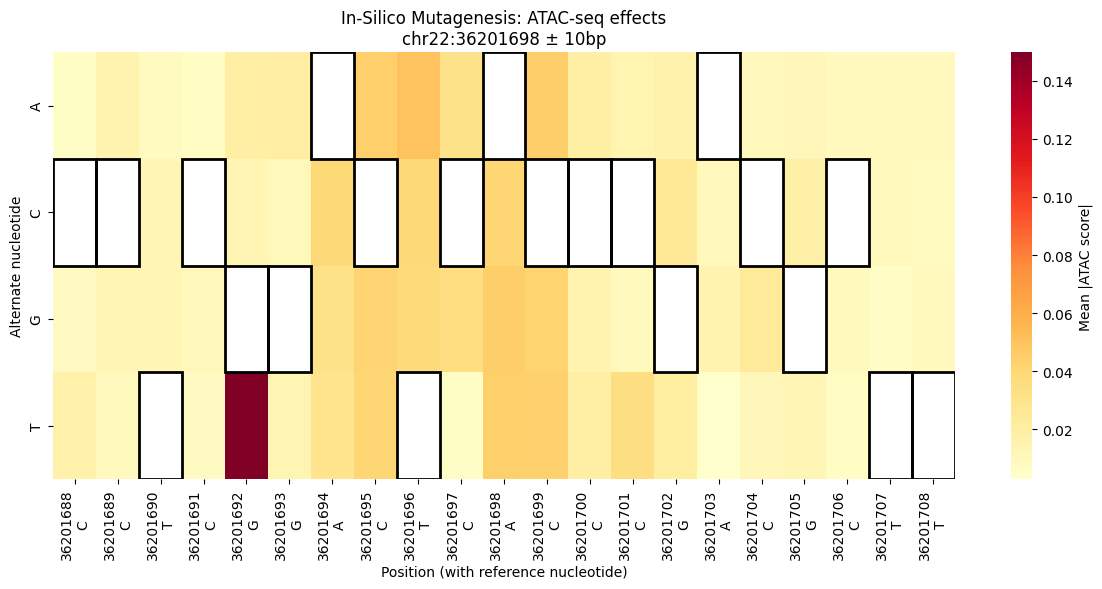

In [8]:
# Get reference sequence for annotation
ref_interval = Interval(
    chrom,
    center_position - window_size // 2 - 1,  # 0-based start
    center_position + window_size // 2,      # 0-based end (exclusive)
)
ref_sequence = scoring_model.fasta.extract(ref_interval)

fig, ax = plt.subplots(figsize=(12, 6))

# Create heatmap
sns.heatmap(
    ism_matrix.T,  # Transpose so nucleotides are on y-axis
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Mean |ATAC score|'},
    xticklabels=[f"{pos}\n{ref_sequence[i]}" for i, pos in enumerate(ism_matrix.index)],
)

# Highlight reference nucleotides (they should be ~0)
for i, pos in enumerate(ism_matrix.index):
    ref_nuc = ref_sequence[i]
    if ref_nuc in nucleotides:
        j = nucleotides.index(ref_nuc)
        ax.add_patch(plt.Rectangle((i, j), 1, 1, fill=False, edgecolor='black', lw=2))

ax.set_xlabel('Position (with reference nucleotide)')
ax.set_ylabel('Alternate nucleotide')
ax.set_title(f'In-Silico Mutagenesis: ATAC-seq effects\n{chrom}:{center_position} ± {window_size//2}bp')

plt.tight_layout()
plt.show()

## 7. Track-Specific ISM Analysis

We can also look at ISM effects on specific cell types or tissues.

In [10]:
# Get track metadata to identify specific cell types
atac_metadata = scoring_model.get_track_metadata('human').get(OutputType.ATAC, [])
# Find indices for specific cell types (e.g., HepG2, K562)
cell_types_of_interest = ['HepG2', 'K562', 'GM12878']
track_indices = {}
for meta in atac_metadata:
    for ct in cell_types_of_interest:
        # Access attributes directly. Use 'or ""' to handle None values safely.
        biosample = meta.biosample_name or ""
        if ct.lower() in str(biosample).lower():
            if ct not in track_indices:
                track_indices[ct] = meta.track_index
print(f"Found track indices: {track_indices}")

Found track indices: {'HepG2': 56, 'K562': 60, 'GM12878': 63}


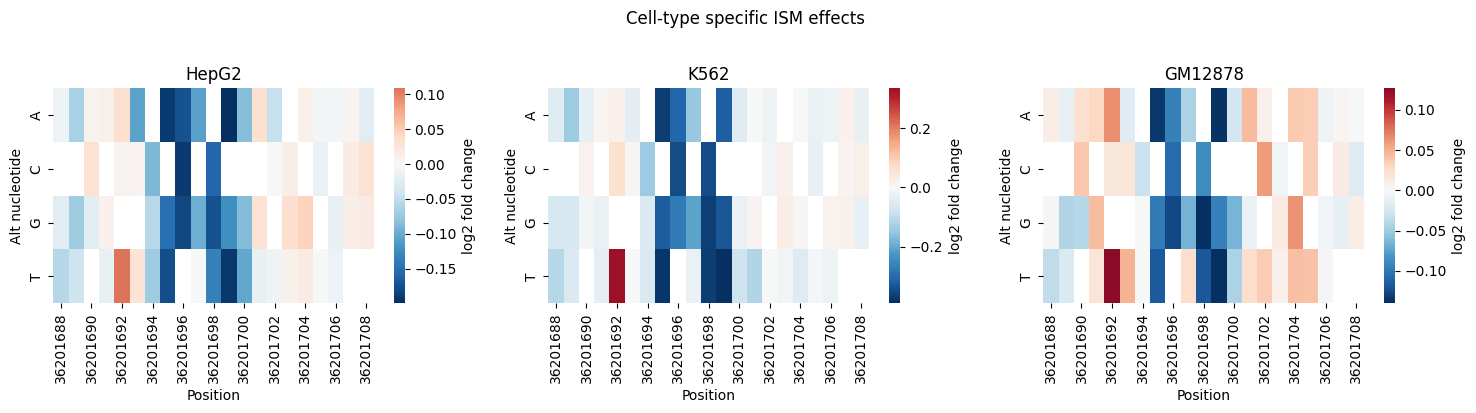

In [12]:
# Create cell-type specific ISM matrices
if track_indices:
    fig, axes = plt.subplots(1, len(track_indices), figsize=(5*len(track_indices), 4))
    if len(track_indices) == 1:
        axes = [axes]
    
    for ax, (cell_type, track_idx) in zip(axes, track_indices.items()):
        if track_idx is None:
            continue
            
        # Extract scores for this specific track
        ct_data = []
        for variant_scores in ism_scores:
            score_obj = variant_scores[0]
            variant = score_obj.variant
            ct_data.append({
                'position': variant.position,
                'alt': variant.alternate_bases,
                'score': score_obj.scores[track_idx].item(),
            })
        
        df_ct = pd.DataFrame(ct_data)
        ct_matrix = df_ct.pivot(index='position', columns='alt', values='score')
        ct_matrix = ct_matrix[nucleotides]
        
        # Plot
        sns.heatmap(
            ct_matrix.T,
            cmap='RdBu_r',
            center=0,
            ax=ax,
            cbar_kws={'label': 'log2 fold change'},
        )
        ax.set_title(f'{cell_type}')
        ax.set_xlabel('Position')
        ax.set_ylabel('Alt nucleotide')
    
    plt.suptitle('Cell-type specific ISM effects', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No matching cell types found in metadata")

## 8. Identify Top-Scoring Variants

Rank variants by their predicted effect to prioritize candidates for follow-up.

In [13]:
# Sort by mean absolute score
df_ism_sorted = df_ism.sort_values('mean_abs_score', ascending=False)

print("Top 10 variants by predicted effect:")
print(df_ism_sorted.head(10).to_string(index=False))

Top 10 variants by predicted effect:
 position ref alt  mean_abs_score  max_score
 36201692   G   T        0.149874   1.824777
 36201696   T   A        0.050089   0.573754
 36201698   A   G        0.045331   0.368140
 36201699   C   A        0.045040   0.369295
 36201695   C   A        0.044385   0.370868
 36201698   A   T        0.043782   0.370014
 36201699   C   T        0.043606   0.390791
 36201699   C   G        0.042117   0.333588
 36201695   C   G        0.041511   0.323265
 36201695   C   T        0.041136   0.378059


In [14]:
# Format as variant strings for downstream use
top_variants = df_ism_sorted.head(5)
print("\nTop 5 variants in VCF format:")
for _, row in top_variants.iterrows():
    variant_str = f"{chrom}:{int(row['position'])}:{row['ref']}>{row['alt']}"
    print(f"  {variant_str} (score: {row['mean_abs_score']:.4f})")


Top 5 variants in VCF format:
  chr22:36201692:G>T (score: 0.1499)
  chr22:36201696:T>A (score: 0.0501)
  chr22:36201698:A>G (score: 0.0453)
  chr22:36201699:C>A (score: 0.0450)
  chr22:36201695:C>A (score: 0.0444)


## 9. Larger Window ISM (Optional)

For a more comprehensive analysis, you can increase the window size.
Note: This increases computation time linearly with window size.

In [ ]:
# Uncomment to run larger ISM (this will take longer)
# larger_window = 101  # 50bp on each side
# 
# ism_scores_large = scoring_model.score_ism_variants(
#     interval=interval,
#     center_position=center_position,
#     scorers=ism_scorers,
#     window_size=larger_window,
#     progress=True,
# )
# print(f"Scored {len(ism_scores_large)} variants in {larger_window}bp window")

## Summary

This notebook demonstrated:

1. **Setting up ISM**: Using `score_ism_variants()` to systematically score all SNVs in a window
2. **Visualization**: Creating position × nucleotide heatmaps to identify functional positions
3. **Cell-type specificity**: Examining effects in specific cell types/tissues
4. **Variant prioritization**: Ranking variants by predicted effect magnitude

ISM is particularly powerful for:
- Fine-mapping causal variants in GWAS loci
- Characterizing the functional grammar of regulatory elements
- Designing saturation mutagenesis experiments

For more details, see the [variant scoring README](../../src/alphagenome_pytorch/variant_scoring/README.md).